# Herramienta multinivel para encontrar el departamento a medida: Webscraping superando captchas y creación de un índice multidimensional a partir de información geocodificada

**Estudiante** Manuel Miller.  
**Materia** Análisis de opinión pública a partir de Redes Sociales y NLP.  
**Carrera** Maestría en generación y análisis de información estadística - UNTREF

---

> ### **IMPORTANTE**
> El sistema completo es una aplicación web con FastAPI, PostgreSQL y un mapa interactivo que se
> levanta con Docker (ver la sección final *"Cómo correr la versión completa"*).
>
> Este notebook reproduce de forma autónoma las técnicas clave del trabajo para que puedan
> evaluarse paso a paso sin necesidad de levantar toda la infraestructura. Se explica la metodología y se
> muestra el código real, acompañado de un ejemplo mínimo ejecutable.
>
> Las credenciales (API key de Google, User-Agent y cookie de ZonaProp) se leen automáticamente del
> `.env` del proyecto si está presente; si corrés en Colab, podés pegarlas a mano en la celda de
> configuración.

## Mapa del notebook (estructura pedida)

1. **Descripción del problema y justificación.**
2. **Origen y adquisición de los datos**  
3. **Limpieza, preparación y modelado del texto**  
4. **Técnicas de análisis aplicadas (paso a paso):**
   - 4.1 Generación dinámica de URLs.
   - 4.2 Web scraping: tecnologías y por qué.
   - 4.3 Cómo se sorteó el CAPTCHA / Cloudflare de ZonaProp.
   - 4.4 Manejo de la base de datos.
   - 4.5 Geocodificación.
   - 4.6 Índice combinado por *spatial join* con fuentes secundarias.
5. **Resultados, visualizaciones y discusión.**
6. **Conclusiones.**

In [66]:
!pip -q install "scrapling[fetchers]" beautifulsoup4 googlemaps shapely folium matplotlib pandas
import re, json
from pathlib import Path
import pandas as pd
from scrapling.fetchers import Fetcher

In [67]:
# === Configuracion: lee credenciales del .env del proyecto si esta presente ===
def cargar_env(rutas=(".env", "../.env", "../../.env")):
    env = {}
    for r in rutas:
        p = Path(r)
        if p.exists():
            for ln in p.read_text(encoding="utf-8").splitlines():
                ln = ln.strip()
                if ln and not ln.startswith("#") and "=" in ln:
                    k, v = ln.split("=", 1)
                    env[k.strip()] = v.strip()
            print("[ok] .env cargado desde", p.resolve())
            return env
    print("[info] no se encontro .env; usando defaults / placeholders (pegar a mano en Colab)")
    return env

ENV = cargar_env()
GOOGLE_MAPS_API_KEY = ENV.get("GOOGLE_MAPS_API_KEY", "")
ZONAPROP_USER_AGENT = ENV.get(
    "ZONAPROP_USER_AGENT",
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
    "(KHTML, like Gecko) Chrome/149.0.0.0 Safari/537.36",
)
ZONAPROP_IMPERSONATE = ENV.get("ZONAPROP_IMPERSONATE", "chrome146")

# La cookie cf_clearance VENCE (horas). Pegá una fresca acá para la demo en vivo de ZonaProp.
# Cómo obtenerla: navegador -> zonaprop -> F12 -> Application -> Cookies -> cf_clearance.
ZONAPROP_CF_CLEARANCE = "AJhd5913.QuRi0K1NNIbHozDJwiarx5ZhozxncMu7BE-1782443820-1.2.1.1-y9IM9Xz.ixRE5fxbgyxlbLMV.PGKmYDuWzJkQQBA7MMCU9hepQQPiDNQIjO8JobF.qAEb9My2ZddmWKMIlybtzoWQRbduQd9o67ku_vzpnvBB3gGTrUaq7LyBkl.GH5KBdjp.oAXbR9vnFZVp3Zg2PWjae64RpAdS1pi17GUkNUZPL7f_CjJ13GbuLfPndFOcD197yzKEKxSwefqRMUGmD99eQvFNBPjmHS69.0PN7WmUxCRG7D51hLo7GIkZdrZXLRxpfDg1CbQfO_g691J7HU.SvTyDiKsSXfS8SRdKtXbjVz5P8tgXpspv4IEWtAaVPdNp.CAZzgo1gE3UEe8Lg"


[ok] .env cargado desde C:\Users\manue\OneDrive - moiguer.com\MIOS_PERSONAL\deptos_scraper\.env


## 1. Descripción del problema y justificación

Buscar departamento en alquiler en la Ciudad de Buenos Aires es un problema de difícil solución para distintos inquilinos. Obviando el problema de la oferta dispersa entre distintos portales, cada uno de ellos ha mejorado mucho en los últimos años ofreciendo buscadores cada vez mas detallados, hasta incluso llegar al punto de permitir dibujar sobre un mapa la zona en la que se quiere alquilar.  

Sin embargo, ¿Qué pasa cuando varios componentes del departamento entran en juego en mi evaluación con pesos distintos? ¿Qué pasa cuando tengo una alta valoración de la proximidad a subtes, espacios verdes, gimnasios u otros puntos de interés que no están integrados en las páginas? La multiplicidad de criteros y las distintas formas de jerarquizarlos, hace que ninguna herramienta actual pueda satisfacer al 100% las necesidades de un inquilino exigente.

**Justificación / relevancia.** 
Surge entonces la necesidad de una herramienta que:  
1. Integre la oferta de distintos portales de publicaciones de alquiler en un mismo lugar
2. Permita buscar transversalmente a través de ellos con uniformidad de criterios
3. Enriquezca estos datos mediante el cruce espacial con otras fuentes secundarias
4. Defina un score según la ponderación que el usuario atribuye a cada uno de los factores y dando como output una única escala de evaluación para las distintas publicaciones.
5. Simplifique la repetición de la búsqueda diaria bajo los mismos criterios generando un listado actualizado de la oferta disponible y relevante  

En sintesis, resulta pertinente el desarrollo de una herramienta con el siguiente flujo de trabajo:

*adquisición → limpieza → enriquecimiento → indicador → visualización*.

## 2. Origen y adquisición de los datos

**Fuentes primarias**
-  (oferta de alquileres):** portales inmobiliarios **ZonaProp** y **ArgenProp**.
Los datos se obtienen por **web scraping** de los listados, parametrizado por perfil de búsqueda
(barrios, tipo de propiedad, rango de precio, ambientes, etc.).
-  Ubicaciones de **gimnasios**: Extraído de las páginas webs de las principales cadenas con metodos simples de web scraping como el uso de la extensión "instant data scraper". Esta recolección no es relevante frente al pipeline central por lo que no se documenta por motivos de espacio

**Fuentes secundarias:**
- Polígonos de **barrios** de CABA (Datos abiertos CABA).
- **Estaciones de subte** y Lineas (Datos abiertos CABA).
- **Espacios verdes públicos** (Datos abiertos CABA).
- **dataset "Callejero"** red de calles en CABA (Datos abiertos CABA).

### 2.1 / 4.1 — Generación dinámica de URLs

Cada portal codifica los filtros de búsqueda **en la propia URL** (no via formularios POST). Por eso
el primer paso es un *constructor de URLs* que, dado un perfil (barrio, tipo, precio, ambientes…),
arma la URL canónica de cada portal. Esto permite **barrer programáticamente** todas las combinaciones
de barrio × tipo y paginar resultados.

Abajo están las funciones **reales** del proyecto (`app/services/url_builder_service.py`).

In [68]:
TYPE_SLUGS = {
    "argenprop": {"departamento": "departamentos", "ph": "ph"},
    "zonaprop":  {"departamento": "departamentos", "ph": "ph"},
}

def build_argenprop_url(barrio, tipo_std, config):
    base = "https://www.argenprop.com"
    tipo_slug = TYPE_SLUGS["argenprop"][tipo_std]
    precio = config.get("precio", {})
    moneda = precio.get("moneda", "pesos")
    rango = f"{moneda}-{precio.get('min', '')}-{precio.get('max', '')}"
    path = f"/{tipo_slug}/alquiler/{barrio}/{rango}"
    query = []
    extras = config.get("extras", {})
    if extras.get("expensas_max"):
        query.append(f"*-{extras['expensas_max']}-expensas")
    if extras.get("balcon") and tipo_std != "ph":
        query.append("con-ambiente-balcon")
    query.append("solo-ver-pesos")
    return f"{base}{path}?{'&'.join(query)}"

def build_zonaprop_url(barrio, tipo_std, config):
    base = "https://www.zonaprop.com.ar"
    tipo_slug = TYPE_SLUGS["zonaprop"][tipo_std]
    parts = [tipo_slug, "alquiler", barrio]
    dorm = config.get("dormitorios", {}); amb = config.get("ambientes", {})
    sup = config.get("superficie", {});   precio = config.get("precio", {})
    if dorm.get("min") and dorm.get("max"):
        parts.append(f"desde-{dorm['min']}-hasta-{dorm['max']}-habitaciones")
    if amb.get("min") and amb.get("max"):
        parts.append(f"desde-{amb['min']}-hasta-{amb['max']}-ambientes")
    if precio.get("min") and precio.get("max"):
        parts.append(f"{precio['min']}-{precio['max']}-{precio.get('moneda', 'pesos')}")
    return f"{base}/{'-'.join(parts)}.html"

# Paginacion (cada portal pagina distinto)
def paginar(base_url, portal, page):
    if page == 1: return base_url
    if portal == "argenprop":
        path, _, qs = base_url.partition("?")
        return f"{path}/pagina-{page}" + (f"?{qs}" if qs else "")
    if portal == "zonaprop":
        return base_url.replace(".html", f"-pagina-{page}.html")
    return base_url

perfil = {"precio": {"min": "", "max": "", "moneda": "pesos"}, "ambientes": {}, "dormitorios": {},
          "superficie": {}, "extras": {}}
for portal, fn in [("argenprop", build_argenprop_url), ("zonaprop", build_zonaprop_url)]:
    u = fn("belgrano", "departamento", perfil)
    print(portal, "pag1:", u)
    print(portal, "pag2:", paginar(u, portal, 2))

argenprop pag1: https://www.argenprop.com/departamentos/alquiler/belgrano/pesos--?solo-ver-pesos
argenprop pag2: https://www.argenprop.com/departamentos/alquiler/belgrano/pesos--/pagina-2?solo-ver-pesos
zonaprop pag1: https://www.zonaprop.com.ar/departamentos-alquiler-belgrano.html
zonaprop pag2: https://www.zonaprop.com.ar/departamentos-alquiler-belgrano-pagina-2.html


## 3. Limpieza, preparación y modelado del texto

Se aplican operaciones de limpieza y tratamientos de datos en distintas partes del proceso, pero principalmente en estos 2 momentos

**Momento 1 — mientras se scrapea (aviso por aviso).** Cada publicación llega como HTML desordenado. Con
BeautifulSoup extraemos los campos (precio, dirección, ambientes…) y limpiamos el texto: sacamos los
símbolos de los precios, descartamos las publicaciones en dólares y dejamos la dirección en una forma
prolija.

**Momento 2 — después, al juntar todo (deduplicación).** Recién cuando tenemos todos los avisos juntos
podemos detectar duplicados: la misma propiedad aparece varias veces, dentro de un mismo portal y
—sobre todo— repetida entre portales, con la dirección escrita de distintas formas. Este paso ocurre al
consolidar los datos en la base.

El **puente** entre los dos momentos es la **normalización de la dirección**: llevar
`"Av. Cabildo 2200 3°B"` y `"AVENIDA CABILDO 2200, piso 3"` a una **misma forma canónica**
(`"avenida cabildo 2200"`). Si dos avisos comparten esa forma (más el precio), son probablemente dos publicaciones para el mismo inmueble.

Abajo están las funciones reales del proyecto (`app/core/normalization.py`).

In [69]:
def clean_text(t):
    if not t: return ""
    return " ".join(str(t).replace("\n", " ").replace("\r", "").split())

def force_int(t):
    if not t: return ""
    if "estrenar" in str(t).lower(): return "0"
    return re.sub(r"[^\d]", "", str(t).replace(".", "").replace(",", ""))

def is_usd(t):
    t = str(t).upper()
    return any(s in t for s in ("USD", "U$S", "US$", "DOLARES"))

# Expansion de abreviaturas + limpieza de ruido (piso, dpto, barrio) para la dirección
_ABBREV = [
    (r"\bav\.?(?=\s|\d|$)", "avenida "), (r"\bpte\.?(?=\s|\d|$)", "presidente "),
    (r"\bgeneral\b", "gral"), (r"\bc\.a\.b\.a\.?\b", ""), (r"\bcaba\b", ""),
    (r"\b(del|de la|de los|de las|de|la|el|los|las)\b", ""), (r"\bsobre\b", ""),
    (r"\bdpto\.?\b", ""), (r"\bpiso\s+\d+", ""), (r"\b\d+\s*[°ºa-zA-Z]\s*[a-z]?\b", ""),
]
_COMP = [(re.compile(p, re.I), r) for p, r in _ABBREV]

def normalize_address(addr):
    if not addr or str(addr).strip() == "": return ""
    s = re.sub(r"[,;:()\[\]]", " ", str(addr).lower().strip())
    for pat, rep in _COMP:
        s = pat.sub(rep, s)
    s = re.sub(r"\s+", " ", s).strip()
    m = re.match(r"^(.+?)\s+(\d+)", s)   # calle + primer numero
    return f"{re.sub(r'\s+', ' ', m.group(1)).strip()} {m.group(2)}" if m else s

def build_dedup_key(portal, direccion, precio):
    p = re.sub(r"[^\d]", "", str(precio)) if precio else ""
    return f"{portal.lower()}|{normalize_address(direccion)}|{p}"

# La misma direccion escrita distinto -> misma forma canonica -> mismo inmueble
for e in ["Av. Cabildo 2200 3°B", "AVENIDA CABILDO 2200, piso 3 dpto B", "O'Higgins 2000 - C.A.B.A."]:
    print(f"{e!r:42} -> {normalize_address(e)!r}")
print("\nmisma clave de dedup:",
      build_dedup_key("zonaprop", "Av. Cabildo 2200", "$ 900.000") ==
      build_dedup_key("zonaprop", "Avenida Cabildo 2200", "900000"))

'Av. Cabildo 2200 3°B'                     -> 'avenida cabildo 2200'
'AVENIDA CABILDO 2200, piso 3 dpto B'      -> 'avenida cabildo'
"O'Higgins 2000 - C.A.B.A."                -> "o'higgins 2000"

misma clave de dedup: True


## 4. Técnicas de análisis aplicadas

### 4.2 — Web scraping: con qué se hizo y por qué (explicado simple)

Para bajar los avisos hay que **pedirle las páginas al servidor del portal y leerlas**. El problema es
que los portales **detectan y bloquean** a los programas que automatizan eso. Las herramientas posibles,
de más pesada a más liviana:

- **Selenium / Playwright (navegadores automatizados).** Manejan por código un navegador *de verdad*
  (Chrome/Firefox). A favor: ejecutan el JavaScript de la página igual que una persona. En contra: son
  **lentos y pesados** (hay que instalar el navegador), gastan mucha memoria y —aunque no se vea— abren
  un navegador por dentro. *Playwright* es una versión más moderna y rápida que *Selenium*, pero la idea
  es la misma.

- **¿Qué es la "huella" TLS / JA3?** Cuando un programa se conecta a un sitio por HTTPS, manda una especie de **huella digital técnica**: qué métodos de cifrado soporta,
  en qué orden, etc. Ese resumen se llama **JA3**. Los navegadores reales tienen un JA3 característico;
  las librerías HTTP comunes de Python (como `requests`) tienen **otro JA3 distinto**, y por eso los
  sitios las reconocen como "bot" al instante, aunque manden los encabezados correctos.

- **`curl_cffi`.** Es una librería que hace pedidos HTTP rápidos, pero **imitando el JA3 de un navegador
  real**. Es decir: la velocidad de un pedido simple, con la huella de Chrome. **No abre ningún
  navegador**; es solo el pedido de red, bien disfrazado.

- **`Scrapling`.** Es la librería que usamos. Por debajo se apoya en `curl_cffi` (para esa imitación de
  huella) y le agrega comodidades para scraping: encabezados realistas, reintentos y parsing.

**Decisión del proyecto:** usar **Scrapling** (HTTP con huella de navegador) en lugar de
Selenium/Playwright. Resultado: scraping **rápido, liviano, sin abrir ninguna ventana** y fácil de
empaquetar en Docker.

In [70]:
from bs4 import BeautifulSoup

def parse_argenprop(html):
    soup = BeautifulSoup(html, "html.parser")
    out = []
    for card in soup.find_all("div", class_="listing__item"):
        d = {}
        try:
            price = card.find("p", class_="card__price")
            if price:
                full = price.get_text().strip()
                if is_usd(full):           # descartamos avisos en dólares
                    continue
                d["Precio"] = force_int(full.split("+")[0] if "+" in full else full)
            exp = card.find("span", class_="card__expenses")
            if exp: d["Expensas"] = force_int(exp.text)
            addr = card.find("p", class_="card__address")
            if addr: d["Direccion"] = clean_text(addr.text)
            t = card.find("h2", class_="card__title")
            d["Titulo"] = clean_text(t.text) if t else ""
            link = card.find("a", href=True)
            if link: d["URL"] = "https://www.argenprop.com" + link["href"]
            out.append(d)
        except Exception:
            continue
    return out

df_argen = pd.DataFrame()
if SCRAPLING_OK:
    try:
        page = Fetcher.get(build_argenprop_url("belgrano", "departamento", perfil),
                           stealthy_headers=True, timeout=30)
        html = page.body.decode("utf-8", "replace") if isinstance(page.body, (bytes, bytearray)) else page.body
        df_argen = pd.DataFrame(parse_argenprop(html))
        print(f"status={page.status}  avisos parseados={len(df_argen)}")
        display(df_argen.head(8))
    except Exception as e:
        print("No se pudo scrapear (red/anti-bot):", e)

[2026-06-26 00:23:51] INFO: Fetched (200) <GET https://www.argenprop.com/departamentos/alquiler/belgrano/pesos-hasta-hasta?solo-ver-pesos> (referer: https://www.google.com/)


status=200  avisos parseados=20


,Precio,Expensas,Direccion,Titulo,URL
0,700000,210000,"Blanco Encalada 2900, Piso 5",Amoblado | Balcón Aterrazado | ALQUILER: $ 700...,https://www.argenprop.com/departamento-en-alqu...
1,1100000,170000,"Montañeses 2700, Piso 8",Balcon Aterrazado - Muy Luminoso,https://www.argenprop.com/departamento-en-alqu...
2,1090000,325000,"Av Gral Luis Maria Campos 1100, Piso 2",AMOBLADO - VIGILANCIA,https://www.argenprop.com/departamento-en-alqu...
3,1800000,250000,"Amenabar 1600, Piso 8",3 amb c/ bcon tza,https://www.argenprop.com/departamento-en-alqu...
4,620000,176000,"DORREGO 2400, Piso 3",Ambiente con cocina americana a gas balcón cft...,https://www.argenprop.com/departamento-en-alqu...
5,2000000,530000,O'higgins 2200,"4 ambientes más dependencia, impecable! cocher...",https://www.argenprop.com/departamento-en-alqu...
6,2100000,600000,"Mariscal Antonio Jose de Sucre 2800, Piso 5",Exclusivo piso en Belgrano,https://www.argenprop.com/departamento-en-alqu...
7,650000,195000,"Av congreso 3200, Piso 1",Moderno y Luminoso Monoambiento con Balcon Al ...,https://www.argenprop.com/departamento-en-alqu...


### 4.3 — Cómo se sorteó la protección de ZonaProp (Cloudflare)

En desarrollo y corriendo el procedimiento desde scripts, abriendo el navegador con selenium, las primeras veces no hubo problema al escrapear ninguna de las páginas, dado que con haber resulto una vez el captcha de ZonaProp el problema desapareció.  
Pero al buscar pasar a un modo de ejecución en segundo plano, ZonaProp respondía con una pantalla de **Cloudflare** para filtrar bots.

Identificamos la cookie llamada **`cf_clearance`**: es el "pase" que Cloudflare entrega una vez que
pasaste la verificación. Si la reusás, te deja entrar sin volver a verificar… con una aclaración.

No alcanza con copiar la cookie. Cloudflare ata esa cookie a tres cosas a la vez: tu
User-Agent (el "nombre" de tu navegador), tu IP y tu huella TLS/JA3. Si copiás la
cookie a un programa común, la huella no coincide y Cloudflare la rechaza.

Entonces reproducimos las tres cosas juntas con Scrapling:
1. la cookie **`cf_clearance`** (extraida manualmente como se explica abajo);
2. el **mismo User-Agent** de ese navegador;
3. una **huella TLS equivalente** con `impersonate="chrome146"` (curl_cffi imita el JA3 de Chrome).

Así el pedido HTTP "parece" exactamente el navegador que ya pasó Cloudflare, y devuelve el listado real.
Es headless (no abre ventana) y rápido.

Se recomienda sacar una nueva cookie por ejecucición por el caso de que venza.

#### Cómo obtener la cookie `cf_clearance`, paso a paso
1. Entrá a ZonaProp en tu navegador (Brave/Chrome) y, si aparece, **pasá la verificación** de Cloudflare.
2. Apretá **F12** (herramientas de desarrollador).
3. Andá a la pestaña **Application** 
4. En el panel izquierdo: **Cookies → `https://www.zonaprop.com.ar`**.
5. Buscá la fila **`cf_clearance`** y copiá su **Value** 
6. Pegalo en `ZONAPROP_CF_CLEARANCE`, en la celda de configuración del inicio.

La imagen muestra dónde están esos pasos en el navegador:

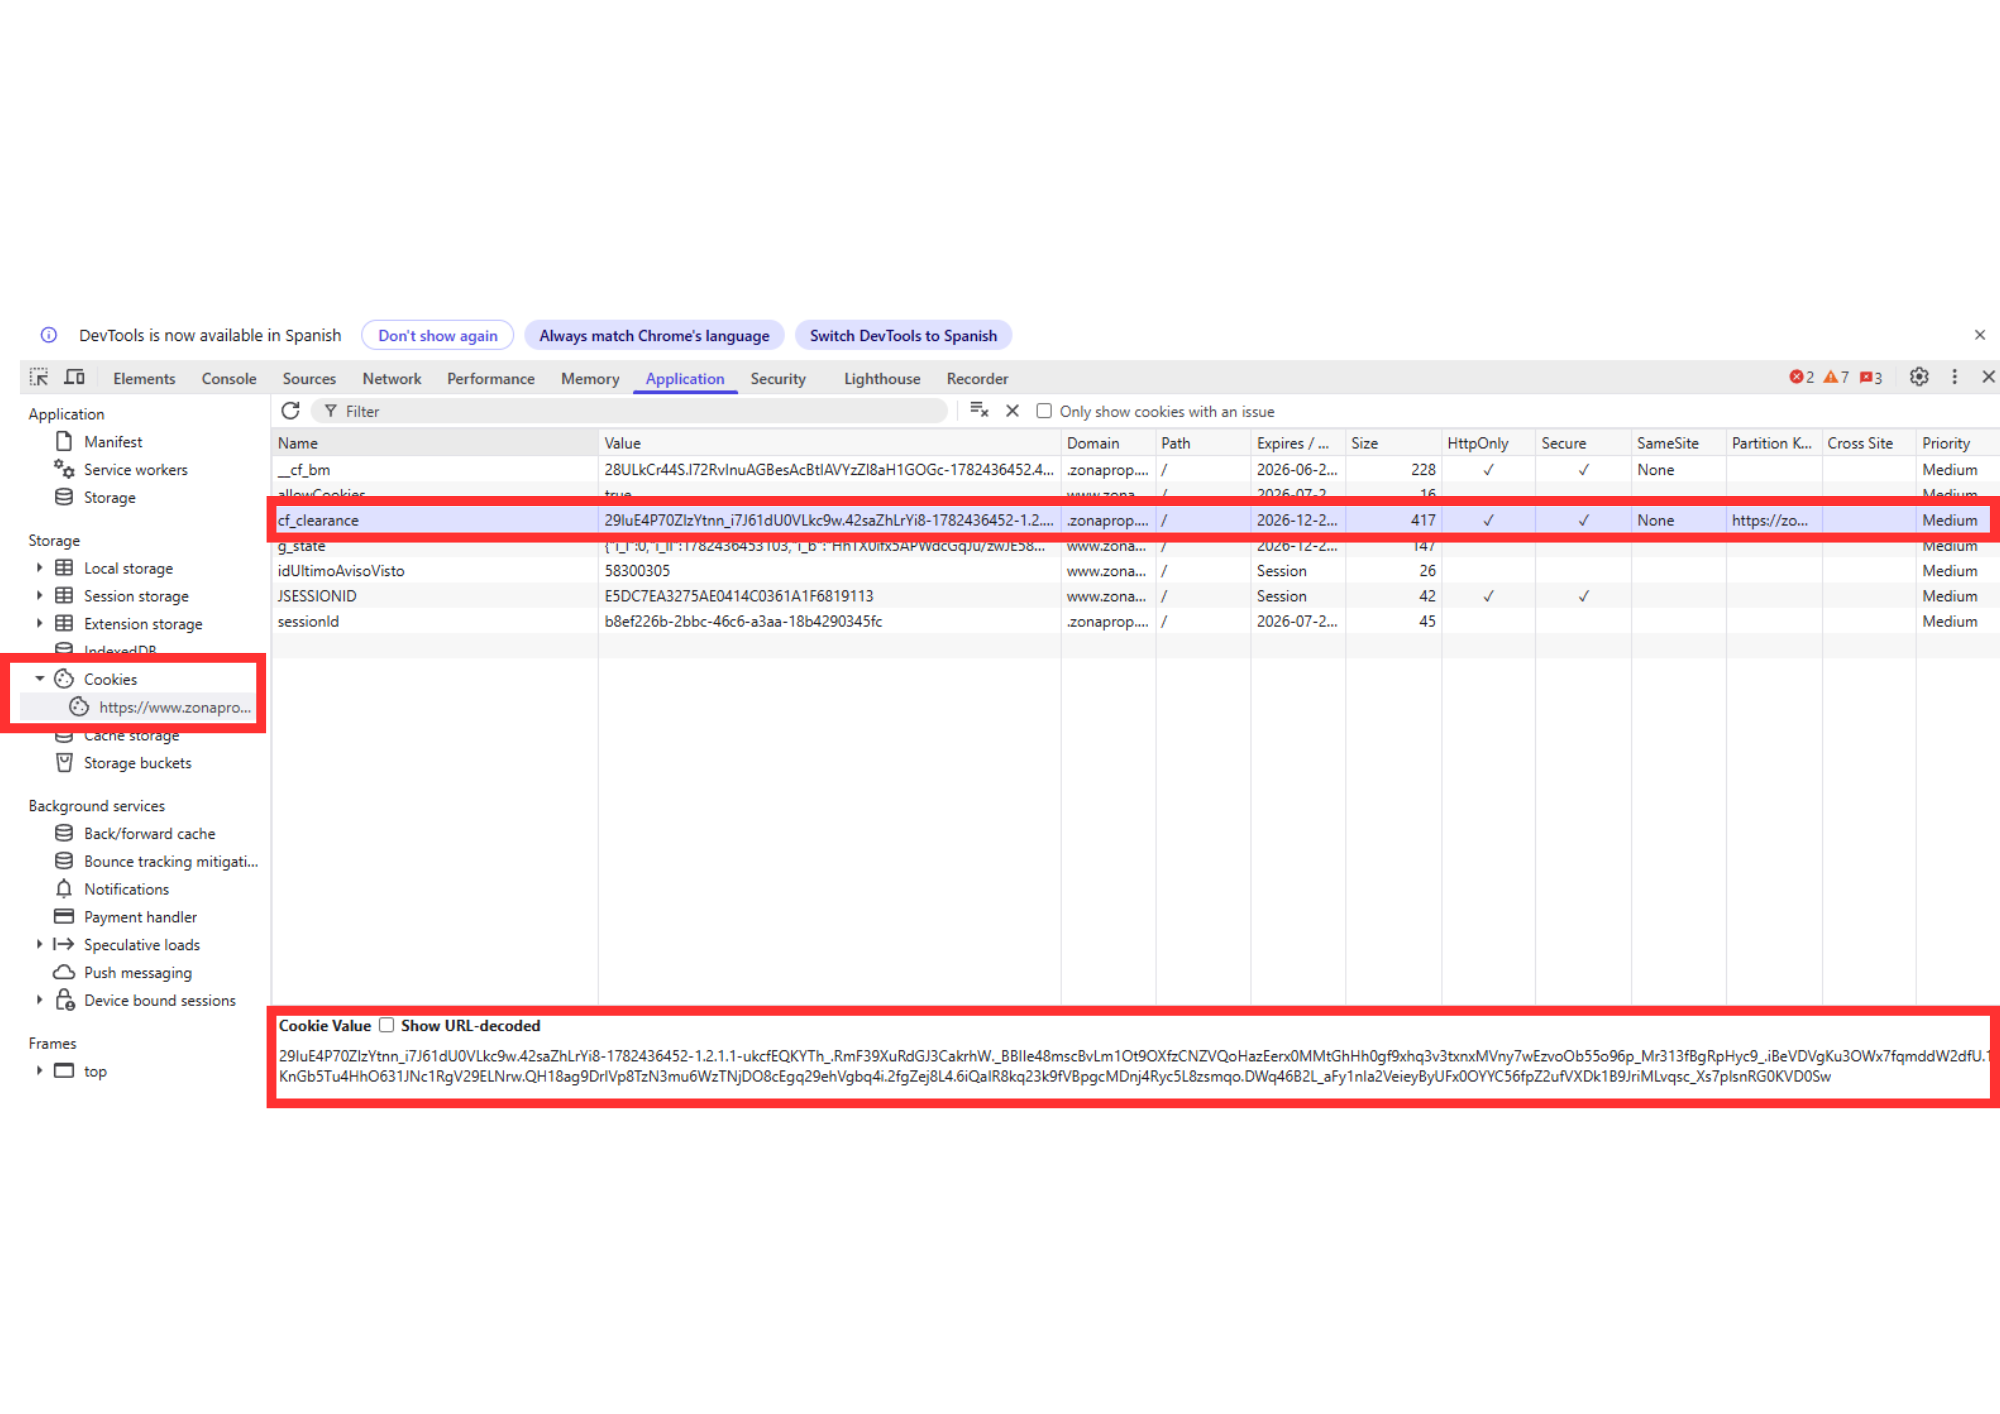

In [71]:
def fetch_zonaprop(url, cf_clearance, ua, impersonate):
    page = Fetcher.get(
        url,
        headers={"User-Agent": ua, "Accept-Language": "es-AR,es;q=0.9,en;q=0.8"},
        cookies={"cf_clearance": cf_clearance},
        impersonate=impersonate,
        stealthy_headers=False, timeout=30, follow_redirects=True,
    )
    body = page.body.decode("utf-8", "replace") if isinstance(page.body, (bytes, bytearray)) else page.body
    bloqueado = getattr(page, "status", 200) in (403, 429, 503) or "just a moment" in body.lower()
    return page, body, bloqueado

if SCRAPLING_OK and ZONAPROP_CF_CLEARANCE:
    u = build_zonaprop_url("belgrano", "departamento", perfil)
    page, body, bloqueado = fetch_zonaprop(u, ZONAPROP_CF_CLEARANCE, ZONAPROP_USER_AGENT, ZONAPROP_IMPERSONATE)
    n = body.count("postingCardLayout-module__posting-card-layout")
    print(f"status={page.status}  bloqueado={bloqueado}  avisos detectados={n}")
    print("=> Cloudflare superado, listado real recibido" if (not bloqueado and n) else "=> revisar la cookie")
else:
    print("[demo ZonaProp saltada] Pegá una cookie cf_clearance fresca en ZONAPROP_CF_CLEARANCE (celda de config).")

[2026-06-26 00:24:03] INFO: Fetched (200) <GET https://www.zonaprop.com.ar/departamentos-alquiler-belgrano.html> (referer: None)


status=200  bloqueado=False  avisos detectados=39
=> Cloudflare superado, listado real recibido


### 4.4 — Cómo se guardan y consolidan los datos

Los datos terminan en una base **PostgreSQL** . El
guardado se hace en **etapas separadas**, a propósito:

1. **Primero, a un archivo temporal** (un `.json` por cada corrida). El scraping no escribe directo a la
   base. ¿Por qué? Si algo falla a mitad la base no queda a
   medio llenar: simplemente se reintenta esa etapa.
2. **Después se geocodifica** ese archivo (le agrega coordenadas).
3. **Recién al final se vuelca a la base**, ya con todo calculado.

**Evitar duplicados al guardar.** Antes de insertar un aviso, el sistema se fija si ya existía y, en
ese caso, lo actualiza en lugar de crear un registro repetido. La verificación por avisos cargados previamente se hace en dos pasos.
   1. ¿hay otro aviso con la misma URL? 
   2. si no, ¿hay otro con la misma clave de dirección + precio ? — esto detecta
      el mismo inmueble publicado en dos portales con URLs distintas.
   Si no aparece en ninguno, se inserta como nuevo.

**Historial.** Cada aviso guarda cuándo se vio por primera y última vez, y cuántas veces.
Cuando un aviso deja de aparecer, no se borra: se marca como inactivo. Así se puede estudiar cómo
evoluciona la oferta (cuánto dura publicado, si bajó de precio…).

La celda siguiente muestra, con datos de ejemplo, cómo se detecta un duplicado por URL y otro por dirección.

In [72]:
ejemplo = [
    {"Portal":"zonaprop","URL":"https://www.zonaprop.com.ar/p/AB-123.html","Direccion":"Av. Cabildo 2200 3B","Precio":"900000"},
    {"Portal":"zonaprop","URL":"https://www.zonaprop.com.ar/p/AB-123.html","Direccion":"Av. Cabildo 2200 3B","Precio":"900000"},     # repetido por URL
    {"Portal":"argenprop","URL":"https://www.argenprop.com/x-9","Direccion":"avenida cabildo 2200 piso 3","Precio":"900.000"},      # mismo inmueble, otro portal
    {"Portal":"argenprop","URL":"https://www.argenprop.com/x-1","Direccion":"Juramento 1500","Precio":"800000"},
]
base, urls_vistas, claves_vistas = [], set(), set()
for it in ejemplo:
    u = (it["URL"] or "").strip().lower()
    k = build_dedup_key(it["Portal"], it["Direccion"], it["Precio"])
    if u in urls_vistas or k in claves_vistas:
        print("DUPLICADO ->", it["Portal"], it["URL"]); continue
    urls_vistas.add(u); claves_vistas.add(k); base.append(it)
print(f"\nAvisos scrapeados: {len(ejemplo)}  ->  únicos en la base: {len(base)}")
pd.DataFrame(base)

DUPLICADO -> zonaprop https://www.zonaprop.com.ar/p/AB-123.html

Avisos scrapeados: 4  ->  únicos en la base: 3


,Portal,URL,Direccion,Precio
0,zonaprop,https://www.zonaprop.com.ar/p/AB-123.html,Av. Cabildo 2200 3B,900000
1,argenprop,https://www.argenprop.com/x-9,avenida cabildo 2200 piso 3,900.000
2,argenprop,https://www.argenprop.com/x-1,Juramento 1500,800000


### 4.5 — Geocodificación

Las direcciones de texto se convierten a **coordenadas (latitud/longitud)** con la **API de Google Maps
(Geocoding)**. Antes se limpia la dirección (se saca `C.A.B.A`, separadores) y se la ancla a
*"Ciudad Autónoma de Buenos Aires, Argentina"* para mejorar la precisión. En el sistema completo se
geocodifica por lotes, guardando el avance cada N direcciones para tolerar interrupciones.

In [73]:
def limpiar_direccion(addr):
    addr = re.sub(r"C\.A\.B\.A|CABA| - ", " ", addr, flags=re.I)
    return f"{addr}, Ciudad Autónoma de Buenos Aires, Argentina"

if GOOGLE_MAPS_API_KEY:
    try:
        import googlemaps
        gm = googlemaps.Client(key=GOOGLE_MAPS_API_KEY)
        for addr in ["Av. Cabildo 2200", "Juramento 1500"]:
            r = gm.geocode(limpiar_direccion(addr))
            if r:
                loc = r[0]["geometry"]["location"]
                print(f"{addr:20} -> lat={loc['lat']:.5f} lon={loc['lng']:.5f}")
    except Exception as e:
        print("Geocoding no disponible:", e)
else:
    print("[geocoding saltado] Falta GOOGLE_MAPS_API_KEY (se lee del .env del proyecto).")

Av. Cabildo 2200     -> lat=-34.56130 lon=-58.45758
Juramento 1500       -> lat=-34.55648 lon=-58.44763


### 4.6 — La creación de índices combinados para cada usuario: enriquecer con datos abiertos y rankear

El objetivo era combinar **precio** y **calidad de ubicación** en un único **puntaje 0–100 comparable**, usando
**fuentes secundarias**: subtes, espacios verdes,
gimnasios, barrios, etc para enriquecer los datos generales del inmueble.

**Pasos:**
1. **Convertir el dataset de calles en un grafo.** Un *grafo* es una red de puntos (**nodos** = esquinas) unidos
   por **aristas** (calles), cada una con su largo en metros. Se arma con `momepy` + `networkx` a partir
   del GeoJSON de calles de la Ciudad.
2. **Medir distancias caminando con Dijkstra.** **Dijkstra** es un algoritmo clásico que, partiendo de un
   punto, encuentra el **camino más corto** hacia todos los demás de la red. Lo usamos para calcular,
   desde cada departamento, **cuántos metros hay que caminar** hasta el subte / espacio verde / gimnasio
   más cercano **siguiendo las calles** — no en línea recta, evitando la sobresimplificación de trabajar con distancias Euclidianas.
3. **Asignar el barrio con un *spatial join*.** Un *spatial join* cruza geometrías; acá preguntamos
   *"¿dentro de qué polígono de barrio cae este punto?"* (punto-en-polígono) para etiquetar cada aviso. Esto se hace porque no podemos confiar en como fueron tageados los muebles por quien lo publicó, debemos corroborar si realmente pertenecen al barrio afirmado.
4. **Normalizar y combinar en un puntaje.** Cada variable se lleva a una escala 0–100 **invertida** (menos
   distancia y menos costo = mejor), comparando **dentro de segmentos comparables** (p. ej. por cantidad de
   ambientes, para no comparar un monoambiente con un 4 ambientes). Luego se combinan con pesos que pueden asignarse segun las consideraciones del usuario, yo definí:
   **costo 40% · cercanía a subte 30% · Cercanía a espacios verdes 20% · cercanía a gimnasios 10%**.

Como no usamos la base de datos, las celdas de abajo **scrapean en vivo ~30 departamentos de
ArgenProp y ~15 de ZonaProp** (ZonaProp solo si está cargada la cookie `cf_clearance`; si falta, se
omite), los geocodifican y corren sobre ellos el algoritmo `compute_metrics_for_items`,
que arma el grafo, corre Dijkstra y calcula el puntaje. (La primera vez tarda ~1 minuto porque carga el
callejero de toda la Ciudad.)

In [ ]:

import sys, time as _t
sys.path.insert(0, ".")   # correr desde la raíz del repo
from app.services.parser_service import parse_argenprop as _pa, parse_zonaprop as _pz

BARRIOS_DEMO = ["belgrano", "palermo", "colegiales", "recoleta", "caballito", "villa-urquiza"]

def _fetch_html(url):
    b = Fetcher.get(url, stealthy_headers=True, timeout=30).body
    return b.decode("utf-8", "replace") if isinstance(b, (bytes, bytearray)) else b

def _valido(it):
    pr = str(it.get("Precio", ""))
    return bool(it.get("Direccion")) and pr.isdigit() and 10_000 <= int(pr) <= 99_000_000

def _agregar(items, barrio, vistos, datos, objetivo):
    for it in items:
        ul = (it.get("URL") or "").lower()
        if not _valido(it) or ul in vistos:
            continue
        vistos.add(ul); it["Barrio"] = barrio; it["Tipo"] = "Departamento"; datos.append(it)
        if len(datos) >= objetivo:
            break

def scrape_argenprop(objetivo=30):
    vistos, datos = set(), []
    for barrio in BARRIOS_DEMO:
        for pg in (1, 2):
            if len(datos) >= objetivo: break
            try:
                _agregar(_pa(_fetch_html(paginar(build_argenprop_url(barrio, "departamento", perfil), "argenprop", pg))),
                         barrio, vistos, datos, objetivo)
            except Exception as ex:
                print("  argenprop falló", barrio, pg, ":", ex)
            _t.sleep(0.3)
        if len(datos) >= objetivo: break
    return datos

def scrape_zonaprop(objetivo=15):
    if not (SCRAPLING_OK and ZONAPROP_CF_CLEARANCE):
        print("ZonaProp omitido (no hay cookie cf_clearance cargada).")
        return []
    vistos, datos = set(), []
    for barrio in BARRIOS_DEMO:
        for pg in (1, 2):
            if len(datos) >= objetivo: break
            url = paginar(build_zonaprop_url(barrio, "departamento", perfil), "zonaprop", pg)
            try:
                _, body, bloq = fetch_zonaprop(url, ZONAPROP_CF_CLEARANCE, ZONAPROP_USER_AGENT, ZONAPROP_IMPERSONATE)
                if bloq:
                    print("  ZonaProp bloqueado (cookie vencida?) -> corto"); return datos
                _agregar(_pz(body), barrio, vistos, datos, objetivo)
            except Exception as ex:
                print("  zonaprop falló", barrio, pg, ":", ex)
            _t.sleep(0.3)
        if len(datos) >= objetivo: break
    return datos

crudos = scrape_argenprop(30) + scrape_zonaprop(15)
print(f"scrapeados en vivo: {len(crudos)} departamentos (ArgenProp + ZonaProp)")

muestra = []
if GOOGLE_MAPS_API_KEY and crudos:
    import googlemaps
    gm = googlemaps.Client(key=GOOGLE_MAPS_API_KEY)
    for it in crudos:
        try:
            r = gm.geocode(limpiar_direccion(it["Direccion"]))
            if r:
                loc = r[0]["geometry"]["location"]; it["lat"], it["lon"] = loc["lat"], loc["lng"]
                muestra.append(it)
        except Exception:
            pass
    print(f"geocodificados: {len(muestra)} (listos para métricas y mapa)")
elif not GOOGLE_MAPS_API_KEY:
    print("Falta GOOGLE_MAPS_API_KEY en el .env: no se puede geocodificar.")

[2026-06-26 00:24:04] INFO: Fetched (200) <GET https://www.argenprop.com/departamentos/alquiler/belgrano/pesos-hasta-hasta?solo-ver-pesos> (referer: https://www.google.com/)
[2026-06-26 00:24:04] INFO: Fetched (200) <GET https://www.argenprop.com/departamentos/alquiler/belgrano/pesos-hasta-hasta?solo-ver-pesos&pagina-2> (referer: https://www.google.com/)
[2026-06-26 00:24:17] INFO: Fetched (200) <GET https://www.zonaprop.com.ar/departamentos-alquiler-belgrano.html> (referer: None)


scrapeados en vivo: 45 departamentos (ArgenProp + ZonaProp)
geocodificados: 45 (listos para métricas y mapa)


In [75]:
# --- Algoritmo REAL del proyecto sobre los deptos en vivo (grafo + Dijkstra + spatial join + score) ---
from app.services.metrics_service import compute_metrics_for_items   # primera vez tarda ~1 min (carga el callejero)

df_metrics = pd.DataFrame()
if muestra:
    df_metrics = pd.DataFrame(compute_metrics_for_items(muestra))
    cols = [c for c in ["Barrio", "barrio_geo", "Precio", "distancia_m_subte",
                        "distancia_m_parque", "distancia_m_gym", "Score"] if c in df_metrics.columns]
    print("Distancias en METROS (caminando, por Dijkstra) y puntaje 0-100:")
    display(df_metrics[cols].sort_values("Score", ascending=False).head(15))
else:
    print("Sin departamentos geocodificados; revisá la celda anterior.")

Distancias en METROS (caminando, por Dijkstra) y puntaje 0-100:


,Barrio,barrio_geo,Precio,distancia_m_subte,distancia_m_parque,distancia_m_gym,Score
40,belgrano,San Nicolas,1000000,106,1444,417,100.000000
37,belgrano,Belgrano,1350000,1015,1385,461,87.820252
23,belgrano,Belgrano,680000,340,1120,339,86.874754
8,belgrano,Monserrat,850000,260,1453,399,85.641829
41,belgrano,Belgrano,800000,585,833,660,85.026894
17,belgrano,Colegiales,980000,429,380,638,84.265507
16,belgrano,Belgrano,730000,196,1830,301,83.157422
4,belgrano,Palermo,620000,311,918,452,81.893608
14,belgrano,Colegiales,1000000,480,494,753,79.088272
13,belgrano,Belgrano,670000,693,1576,329,74.443910


## 5. Resultados, visualizaciones y discusión

Usamos los departamentos scrapeados y geocodificados y armamos el mapa interactivo (Leaflet, vía `folium`), igual que la vista principal
de la app. 

In [79]:
# Usamos los departamentos scrapeados y geocodificados en vivo (sección 4.6), sin base de datos
df_full = pd.DataFrame()

tmp = df_metrics.rename(columns={"Precio": "precio", "barrio_geo": "barrio", "Score": "score"})
cols = [c for c in ["lat", "lon", "precio", "barrio", "score"] if c in tmp.columns]
df_full = tmp[cols].dropna(subset=["lat", "lon"])
print("departamentos para el mapa:", len(df_full))

departamentos para el mapa: 45


In [ ]:
# Mapa interactivo (Leaflet/folium) con capas seleccionables
import folium, geopandas as gpd
try:    
    SH = "shapes"
    def color_score(s):
        try: s = float(s)
        except Exception: return "#888888"
        return "#1a9641" if s >= 66 else ("#fdae61" if s >= 33 else "#d73027")

    m = folium.Map(location=[-34.60, -58.44], zoom_start=12, tiles="cartodbpositron")

    # Capa: departamentos coloreados por puntaje
    fg = folium.FeatureGroup(name="Departamentos (por puntaje)", show=True)
    for _, r in df_full.iterrows():
        folium.CircleMarker([r["lat"], r["lon"]], radius=4, color=color_score(r.get("score")),
            fill=True, fill_opacity=0.85,
            popup=f"{r.get('barrio','')} · puntaje {float(r.get('score',0)):.0f} · ${int(r.get('precio') or 0):,}"
        ).add_to(fg)
    fg.add_to(m)

    # Capa: líneas de subte
    try:
        sl = gpd.read_file(f"{SH}/subte_lineas.geojson")
        folium.GeoJson(sl, name="Subte (líneas)",
                       style_function=lambda x: {"color": "#6d28d9", "weight": 3}).add_to(m)
    except Exception as e:
        print("subte_lineas:", e)

    # Capa: estaciones de subte
    try:
        es = gpd.read_file(f"{SH}/estaciones_de_subte.geojson")
        fes = folium.FeatureGroup(name="Subte (estaciones)", show=False)
        for _, r in es.iterrows():
            c = r.geometry.centroid
            folium.CircleMarker([c.y, c.x], radius=3, color="#6d28d9", fill=True, fill_opacity=1).add_to(fes)
        fes.add_to(m)
    except Exception as e:
        print("estaciones:", e)

    # Capa: gimnasios
    try:
        gy = gpd.read_file(f"{SH}/gimnasios.geojson")
        fgy = folium.FeatureGroup(name="Gimnasios", show=False)
        for _, r in gy.iterrows():
            c = r.geometry.centroid
            folium.CircleMarker([c.y, c.x], radius=4, color="#0ea5e9", fill=True, fill_opacity=0.9).add_to(fgy)
        fgy.add_to(m)
    except Exception as e:
        print("gimnasios:", e)

    folium.LayerControl(collapsed=False).add_to(m)
    display(m)
except Exception as e:
    print("folium no disponible (instalá con: pip install folium):", e)

### Discusión

- El **puntaje combinado** ordena propiedades que el precio solo no distingue: un departamento más caro
  puede quedar mejor rankeado si está mucho más cerca del subte y de un parque, y viceversa. La
  **normalización por segmento** evita comparar cosas distintas (un monoambiente contra un 4 ambientes).
- La **deduplicación por texto** es decisiva: sin ella, los portales inflan artificialmente la oferta y
  sesgan cualquier estadística (un mismo aviso contado 3 veces).
- Usar **distancias por la red de calles (Dijkstra)** en vez de línea recta da una medida fiel de
  "caminabilidad", que es lo que realmente importa para vivir en el lugar.
- La decisión de **scraping HTTP con huella de navegador** (en vez de un navegador automatizado) hizo el
  sistema rápido y empaquetable; y la combinación **cookie `cf_clearance` + User-Agent + huella JA3** fue
  la solución más efectiva para sumar ZonaProp. Sin embargo el proceso sostiene este paso manual de copiar la cookie lo que complica la escabilidad futura.

## 6. Conclusiones

- Se construyó un pipeline **reproducible de punta a punta**: adquisición (scraping con URLs dinámicas y
  *bypass* de Cloudflare), limpieza y **modelado de texto** para deduplicar, **geocodificación**,
  enriquecimiento con **fuentes secundarias** vía *spatial join* y **Dijkstra**, y un **índice combinado**
  modificable a demanda.
- El resultado responde al problema planteado: **consolida y compara objetivamente** la oferta de
  alquileres de CABA, integrando precio real y calidad de ubicación en un solo indicador.
- Las decisiones de ingeniería (guardado en etapas, reintentos, scraping sin navegador) priorizan
  **robustez y reproducibilidad**, condición necesaria para un análisis serio.
- **Líneas futuras:** sumar más portales, analizar la evolución de precios en el tiempo (el historial ya
  se captura) y automatizar la extracción de la cookie o buscar una alternativa superadora frente al captcha.

## Apéndice — Qué es cada parte del proyecto y para qué sirve

El sistema completo es una **aplicación web** (no solo este notebook). El flujo general es:

> **perfil de búsqueda → generar URLs → scraping (archivo temporal) → geocodificación → métricas y
> guardado en la base → visualización (mapa / ranking)**

### Código de la aplicación (`app/`)
| Elemento | Para qué sirve |
|---|---|
| `app/main.py` | Arma y arranca la aplicación web (FastAPI). |
| `app/config.py` | Lee la configuración del `.env` (claves, User-Agent y huella de ZonaProp, etc.). |
| `app/database.py` | Conexión a PostgreSQL (motores asíncrono y sincrónico). |
| `app/dependencies.py` | Utilidades de la web: dar la sesión de base y saber qué usuario está logueado. |
| `app/core/security.py` | Contraseñas cifradas (bcrypt) y tokens de login (JWT). |
| `app/core/normalization.py` | Limpieza de direcciones y **clave de deduplicación** (sección 3). |
| `app/core/constants.py` | Listas de barrios y tipos, **pesos del puntaje** y parámetros de Dijkstra. |
| `app/models/` | Definición de las tablas: `User`, `Perfil`, `Departamento`, `ScrapeRun` (corrida de scraping). |
| `app/schemas/` | Validación de los datos que entran/salen de la web (Pydantic). |
| `app/routers/` | Los "endpoints" de la web: `auth` (login), `ui` (páginas), `departamentos`, `perfiles`, `scraping` (disparar y seguir corridas), `shapes` (entrega los GeoJSON al mapa). |
| `app/services/url_builder_service.py` | **Genera las URLs** de búsqueda de cada portal (sección 4.1). |
| `app/services/parser_service.py` | **Parsers**: convierten el HTML de cada portal en datos (sección 4.2). |
| `app/services/scraping_service.py` | **Motor de scraping**: pide las páginas (Scrapling), pagina, filtra, inyecta la cookie de ZonaProp y guarda en el archivo temporal (sección 4.3/4.4). |
| `app/services/consolidation_service.py` | **Geocodificación** y **guardado/deduplicación** en la base (sección 4.4/4.5). |
| `app/services/metrics_service.py` | **Grafo del callejero, Dijkstra, spatial join y puntaje** (sección 4.6). |
| `app/templates/` | Las páginas web (login, **mapa**, **ranking**, panel de scraping). |
| `app/static/` | Archivos de la web (JavaScript, CSS). |

### Datos y soporte
| Elemento | Para qué sirve |
|---|---|
| `shapes/` | Capas geoespaciales (fuentes secundarias): barrios, subte (estaciones y líneas), espacios verdes, **callejero** y gimnasios. |
| `migrations/` | Versionado del esquema de la base (Alembic): crea/actualiza las tablas. |
| `scripts/create_admin.py` | Crea el usuario administrador inicial. |
| `seed/` | Datos iniciales opcionales para precargar la base. |
| `docs/zonaprop_cookie.md` | Instructivo para obtener la cookie `cf_clearance`. |

### Empaquetado y configuración
| Elemento | Para qué sirve |
|---|---|
| `Dockerfile` | Receta para construir la imagen de la app. |
| `docker-compose.yml` | Levanta todo junto: **PostgreSQL + la app**. |
| `entrypoint.sh` | Al arrancar: corre migraciones, crea el admin, carga el seed e inicia la web. |
| `requirements.txt` | Dependencias de Python. |
| `.env` / `.env.example` | Configuración y credenciales (no se sube el `.env` real). |

### Cómo correr la versión completa
```bash
cp .env.example .env     # completar POSTGRES_PASSWORD, SECRET_KEY, ADMIN_PASSWORD, GOOGLE_MAPS_API_KEY
docker compose up -d     # levanta PostgreSQL + la app + migraciones + seed
# Abrir http://localhost:8000  (panel de scraping, mapa y ranking)
```
Para ZonaProp, además, hay que pegar una cookie `cf_clearance` en el panel de scraping (ver
`docs/zonaprop_cookie.md`). **Repositorio (opcional):** _(pegar enlace si se publica)_.